# Quantification of Mitochondria in 2D Fluorescent Stacks
- *Isobel Taylor-Hearn, 2023*
- Requires a fluorescent image stack containing (at least) a nuclear channel and mitochondria channel

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import math
import os
import pathlib

import skimage
from skimage.feature import peak_local_max
from skimage import util,  restoration
from skimage.filters import threshold_otsu, threshold_isodata
from skimage.segmentation import clear_border, expand_labels, watershed
from skimage.measure import label, regionprops_table
from skimage.morphology import remove_small_holes, remove_small_objects, closing,  disk, dilation
from scipy.ndimage import distance_transform_edt
from scipy import ndimage as ndi
from tifffile import imread
from skimage.filters import try_all_threshold

import warnings
warnings.filterwarnings("ignore")
import pathlib

import contextlib
import joblib
from tqdm import tqdm
from joblib import Parallel, delayed

In [3]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """
    Enables parallel jobs to run and display of a tqdm progress bar.

    Parameters:
    -----------
    tqdm_object : tqdm
        The tqdm progress bar instance to be updated.

    """
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

In [4]:
def convert(img, target_type_min, target_type_max, target_type):
    """
    Converts an image to a specified data type while scaling its intensity values.

    This function rescales the intensity values of an image from its original range 
    to a new target range specified by `target_type_min` and `target_type_max`, and 
    then converts it to the desired data type.

    This step is required as deconvolved images are not always scaled 0->255! 

    Parameters:
    -----------
    img : numpy.ndarray
        The input image array to be converted.
    target_type_min : int or float
        The minimum value of the target intensity range.
    target_type_max : int or float
        The maximum value of the target intensity range.
    target_type : numpy.dtype
        The desired data type of the output image (e.g., np.uint8, np.float32).

    Returns:
    --------
    new_img : numpy.ndarray
        The rescaled image with values mapped to the new intensity range and converted 
        to the specified data type.

    Notes:
    ------
    - This function performs a linear transformation to scale pixel values.
    - It ensures that the output values are properly mapped between `target_type_min` and 
      `target_type_max`.
    """
    imin = img.min()
    imax = img.max()

    a = (target_type_max - target_type_min) / (imax - imin)
    b = target_type_max - a * imax
    new_img = (a * img + b).astype(target_type)
    return new_img

In [28]:
def add_image_details(df, filename):
    """
    Adds experimental details extracted from the filename to a dataframe.

    This function parses the filename to infer experimental details such as 
    well number, imaging day, mechanical stiffness condition, and treatment type.
    The extracted details are appended as new columns to the dataframe.

    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe to which image metadata will be added.
    filename : str
        The filename of the image, used to extract experimental details.

    Returns:
    --------
    df : pandas.DataFrame
        The updated dataframe with the following added columns:
        - 'filename': The original filename.
        - 'cell_type': L_LNS or M_LNS
        - 'treatment': Blebbistatin, ROCKi, or untreated
        - 'timepoint': 0hr, 1hr, or 24hr
    """

    df["filename"] = filename
    if "l_nls" in str(filename).lower():
        df["cell_type"] = "L_LNS"
    elif "m_nls" in str(filename).lower():
        df["cell_type"] = "M_LNS"
    else:
        df["cell_type"] = "OTHER"
    if "bleb" in str(filename).lower():
        df["treatment"] = "blebbistatin" 
    elif "rock" in str(filename).lower():
        df["treatment"] = "ROCKi"  
    else:
        df["treatment"] = "untreated"  
    if "1hr" in str(filename).lower():
        df["timepoint"] = "1hr" 
    elif "24hr" in str(filename).lower():
        df["timepoint"] = "24hr"
    else:
        df["timepoint"] = "0hr"

    return df

In [29]:
def segment_nuclei(dapi, pixel_size):
    """
    Segment nuclei and use a watershed segmentation to separate touching objects.
    Filter out any objects below a defined area cutoff.
    Acquired images did not have a membrane marker. Therefore, the code assumes that the border between two cells lies halfway between
        the shortest distance between their nuclei.
    Cell bodies are therefore approximated by expanding nuclear labels without overlap until they fill the image. Cells that touch the border
        or contain nuclei larger than a 15 µm radius equivalent are removed from the analysis.

    Parameters
    ----------
    dapi : ndarray
        Grayscale image of nuclei stained with DAPI.
    pixel_size : float
        Pixel size in microns (µm), used to filter out overly large nuclei.

    Returns
    -------
    dapi_labels : ndarray (int)
        Labeled image of segmented nuclei, where each nucleus has a unique label.
    valid_cell_labels : ndarray (int)
        Labeled image of cell regions corresponding to valid cells. Cells are valid if they don't touch the image border and
            have nuclei smaller than a 15 µm radius equivalent.
    """
    ################## Segment all nuclei #######################################################################################################
    thresh = threshold_otsu(dapi)
    dapi_processed = dapi > thresh
    dapi_processed = closing(dapi_processed, disk(5))
    dapi_processed = remove_small_holes(dapi_processed, area_threshold = 10000)
    dapi_processed = remove_small_objects(dapi_processed, min_size=10000)
    dapi_labels = label(dapi_processed)
    distances = ndi.distance_transform_edt(dapi_processed)
    coordinates = peak_local_max(distances, min_distance = 60) # min_distance = min separation of nuclear COMs
    marker_locations = coordinates.data
    markers = np.zeros(dapi_processed.shape, dtype=np.uint32)
    marker_indices = tuple(np.round(marker_locations).astype(int).T)
    markers[marker_indices] = np.arange(len(marker_locations)) + 1
    markers_big = dilation(markers, disk(5))
    dapi_labels_ws = watershed(-distances, markers_big, mask=dapi_processed)
    dapi_labels = label(dapi_labels_ws + dapi_labels)
    ################## Approximate cell boundaries and exclude cells that touch the border from analysis #########################################
    all_cells_labels = clear_border(expand_labels(dapi_labels, 1000)) # any cells that don't touch the border
    nuclear_props = regionprops_table(dapi_labels, dapi, properties=("label", "area"))  
    condition = (nuclear_props['area'] <= np.pi *((15*pixel_size)**2)) # filter out any cells with nuclei more than 15um radius equivalent
    input_labels = nuclear_props['label']
    output_labels = input_labels * condition
    valid_cell_labels = util.map_array(all_cells_labels, input_labels, output_labels) # only keep the cells with nuclei that pass the area test
    return dapi_labels, valid_cell_labels

In [30]:
def segment_nuclei_and_quantify_protein(image_paths, i, to_plot = True, membrane_channel=3, dapi_channel = 2, protein_of_interest_1_name="YAP", protein_of_interest_1_channel = 0, protein_of_interest_2_name="GFP", protein_of_interest_2_channel = 1, pixel_size = 7.4627):
    """
    Segment nuclei and mitochondria from a multi-channel image and quantify mitochondrial content per cell.

    This function processes a specified image from a list of file paths, segments nuclei and cells using
    the DAPI channel, and segments mitochondria using a mitochondrial fluorescence channel. It optionally 
    visualizes the segmentation and performs quantification of mitochondrial area per cell, as well as the 
    distribution of mitochondria as a function of distance from the nucleus.

    Parameters
    ----------
    image_paths : list of str
        List of file paths to multi-channel microscopy images.
    i : int
        Index of the image in `image_paths` to process.
    to_plot : bool, optional (default=True)
        Whether to generate and save a plot showing segmentation steps.
    dapi_channel : int, optional (default=0)
        Channel index for DAPI (nuclear stain).
    membrane_channel : int, optional (default=1)
        Channel index for membrane stain.
    protein_of_interest_1_name : str, optional (default="YAP")
        Name of the first protein of interest for labeling purposes.
    protein_of_interest_1_channel : int, optional (default=0)
        Channel index for the first protein of interest.
    protein_of_interest_2_name : str, optional (default="GFP")
        Name of the second protein of interest for labeling purposes.
    protein_of_interest_2_channel : int, optional (default=1)
        Channel index for the second protein of interest.

    pixel_size : float, optional (default=7.4627, this is correct for the Zeiss Axio Imager 63x lens)
        Pixel size in microns, used to convert area and distance to physical units.

    Returns
    -------
    all_props : pandas.DataFrame
        DataFrame containing quantified properties per cell, including:
        - 'file': Filename of the processed image.
        - '{protein_of_interest_1_name}_cell': Total intensity of protein of interest 1 in each cell.
        - '{protein_of_interest_1_name}_nucleus': Total intensity of protein of interest 1 in each nucleus.
        - '{protein_of_interest_1_name}_nucleus/cell': Ratio of nuclear to cellular intensity for protein of interest 1.
        - '{protein_of_interest_2_name}_cell': Total intensity of protein of interest 2 in each cell (if applicable).
        - '{protein_of_interest_2_name}_nucleus': Total intensity of protein of interest 2 in each nucleus (if applicable).
        - '{protein_of_interest_2_name}_nucleus/cell': Ratio of nuclear to cellular intensity for protein of interest 2 (if applicable).
        - 'nuc/cell_area': Ratio of nuclear area to cell area.
    """
    filename = os.path.basename(image_paths[i])
    try:
        image = imread(image_paths[i])
        dapi = convert(image[dapi_channel,:,:], 0, 255, np.uint8)
        membrane = convert(image[membrane_channel,:,:], 0, 255, np.uint8)

        protein_of_interest_1 = convert(image[protein_of_interest_1_channel,:,:], 0, 255, np.uint8)
        if protein_of_interest_2_channel is not None:
            protein_of_interest_2 = convert(image[protein_of_interest_2_channel,:,:], 0, 255, np.uint8)

        rgb_image = np.stack([protein_of_interest_1, protein_of_interest_2, dapi], axis=-1)

        dapi_labels, cell_labels = segment_nuclei(dapi, pixel_size=pixel_size)

        cell_props = pd.DataFrame(regionprops_table(cell_labels, properties =("label", "area"))).rename(columns={'area': 'cell_area_pixel'})
        nuclear_props = pd.DataFrame(regionprops_table(dapi_labels, properties =("label", "area"))).rename(columns={'area': 'nuclear_area_pixel'})
        all_props = cell_props.merge(nuclear_props)
        all_props = add_image_details(all_props, filename)
        all_props[f"{protein_of_interest_1_name}_cell"] = all_props.apply(lambda row: protein_of_interest_1[cell_labels == row["label"]].sum(), axis = 1)
        all_props[f"{protein_of_interest_1_name}_nucleus"] = all_props.apply(lambda row: protein_of_interest_1[(cell_labels == row["label"]) & (dapi_labels == row["label"])].sum(), axis = 1) 
        all_props[f"{protein_of_interest_1_name}_nucleus/cell"] = all_props[f"{protein_of_interest_1_name}_nucleus"]/all_props[f"{protein_of_interest_1_name}_cell"]
        if protein_of_interest_2_channel is not None:
            all_props[f"{protein_of_interest_2_name}_cell"] = all_props.apply(lambda row: protein_of_interest_2[cell_labels == row["label"]].sum(), axis = 1)
            all_props[f"{protein_of_interest_2_name}_nucleus"] = all_props.apply(lambda row: protein_of_interest_2[(cell_labels == row["label"]) & (dapi_labels == row["label"])].sum(), axis = 1) 
            all_props[f"{protein_of_interest_2_name}_nucleus/cell"] = all_props[f"{protein_of_interest_2_name}_nucleus"]/all_props[f"{protein_of_interest_2_name}_cell"]
        all_props["nuc/cell_area"] = all_props["nuclear_area_pixel"]/all_props["cell_area_pixel"]

        if to_plot == True:
            fig, ax = plt.subplots(ncols = 3, figsize=(20,5))
            ax[0].imshow(rgb_image)
            ax[1].imshow(dapi, alpha = 0.7, cmap="gray", interpolation = "none")
            ax[1].imshow(np.ma.masked_where(dapi_labels == 0, dapi_labels), cmap="jet", alpha=0.5, interpolation="none")
            ax[1].imshow(np.ma.masked_where(cell_labels == 0, cell_labels), cmap="jet", alpha=0.5, interpolation="none")
            ax[2].imshow(membrane, alpha = 0.7, cmap="gray", interpolation = "none")
            ax[2].imshow(np.ma.masked_where(dapi_labels == 0, dapi_labels), cmap="jet", alpha=0.3, interpolation="none")
            ax[2].imshow(np.ma.masked_where(cell_labels == 0, cell_labels), cmap="jet", alpha=0.3, interpolation="none")
            # ax[2].imshow(rgb_image)
            # ax[3].imshow(np.ma.masked_where((dapi_labels == 0) | (cell_labels == 0), dapi_labels), alpha=1, cmap="gray", interpolation="none")
            for a in ax:
                a.axis("off")
            plt.savefig(f"{filename}_segmentation.png", bbox_inches='tight')
        
        return all_props.reset_index(drop=True)
    except:
        return pd.DataFrame([{"image": filename, "cell_type":"FAIL"}])



C:\Users\itayl\Dropbox (Personal)\Shared_With_Me\Untransfected_M_NLS_L_NLS_Bleb_ROCKi_YAP_GFP\Untreated\L_NLS_untreated_Composite_5.tif


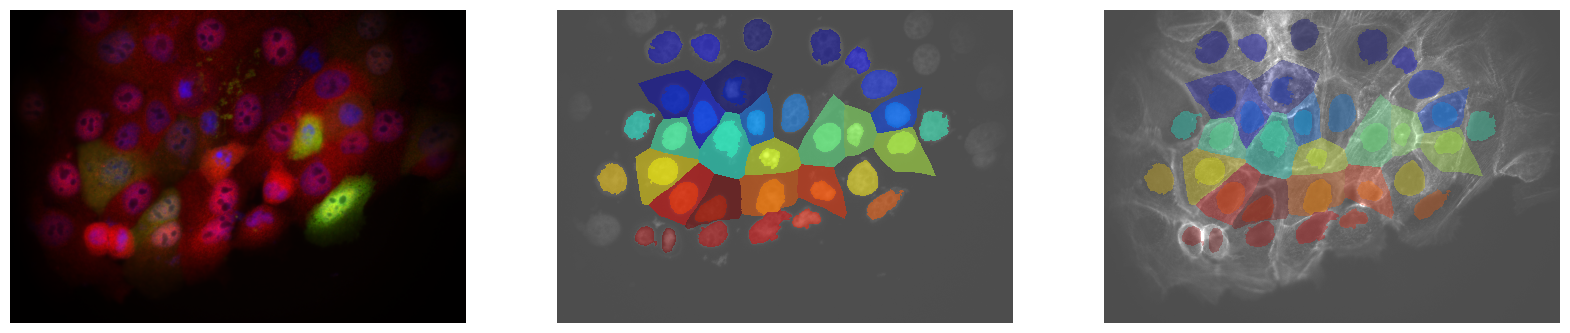

In [31]:
root= "C:\\Users\\itayl\\Dropbox (Personal)\\Shared_With_Me\\Untransfected_M_NLS_L_NLS_Bleb_ROCKi_YAP_GFP"
image_paths = list(pathlib.Path(root).glob("**/*.tif"))
i = 125
print(image_paths[i])
all_props = segment_nuclei_and_quantify_protein(image_paths, i)


In [32]:
all_props

,label,cell_area_pixel,nuclear_area_pixel,filename,cell_type,treatment,timepoint,YAP_cell,YAP_nucleus,YAP_nucleus/cell,GFP_cell,GFP_nucleus,GFP_nucleus/cell,nuc/cell_area
0,7,112147.0,23484.0,L_NLS_untreated_Composite_5.tif,L_LNS,untreated,0hr,8001467,1829555,0.228652,575291,105111,0.182709,0.209404
1,8,98670.0,29505.0,L_NLS_untreated_Composite_5.tif,L_LNS,untreated,0hr,6317028,2457129,0.388969,388295,106427,0.274088,0.299027
2,10,66522.0,28797.0,L_NLS_untreated_Composite_5.tif,L_LNS,untreated,0hr,4710687,1877651,0.398594,361688,166171,0.459432,0.432894
3,11,71252.0,24921.0,L_NLS_untreated_Composite_5.tif,L_LNS,untreated,0hr,6208369,2021761,0.325651,1581947,596426,0.377020,0.349759
4,12,61132.0,18987.0,L_NLS_untreated_Composite_5.tif,L_LNS,untreated,0hr,3678350,1141418,0.310307,981143,358440,0.365329,0.310590
5,15,115320.0,34067.0,L_NLS_untreated_Composite_5.tif,L_LNS,untreated,0hr,6567025,2154896,0.328139,2143002,762236,0.355686,0.295413
6,16,69235.0,25638.0,L_NLS_untreated_Composite_5.tif,L_LNS,untreated,0hr,5079195,1837847,0.361838,688222,151749,0.220494,0.370304
7,17,112289.0,30487.0,L_NLS_untreated_Composite_5.tif,L_LNS,untreated,0hr,10268510,3199856,0.311618,1289115,239462,0.185757,0.271505
8,18,64749.0,14221.0,L_NLS_untreated_Composite_5.tif,L_LNS,untreated,0hr,8064305,1715364,0.212711,5766332,1783560,0.309306,0.219633
9,19,93852.0,24195.0,L_NLS_untreated_Composite_5.tif,L_LNS,untreated,0hr,7869796,2484595,0.315713,606160,148705,0.245323,0.257800


In [33]:
with tqdm_joblib(tqdm(desc="Image Analysis", total=len(image_paths))) as progress_bar:
    output = Parallel(n_jobs=4)(delayed(segment_nuclei_and_quantify_protein)(image_paths, i, to_plot=False) for i in range(len(image_paths)))
total_area = pd.concat(output)
total_area.to_csv("yap_localisation.csv")


Image Analysis: 100%|██████████| 150/150 [09:45<00:00,  3.90s/it]


In [34]:
data = pd.read_csv("yap_localisation.csv")

In [46]:
my_cols = ["red", "dodgerblue", "limegreen"]

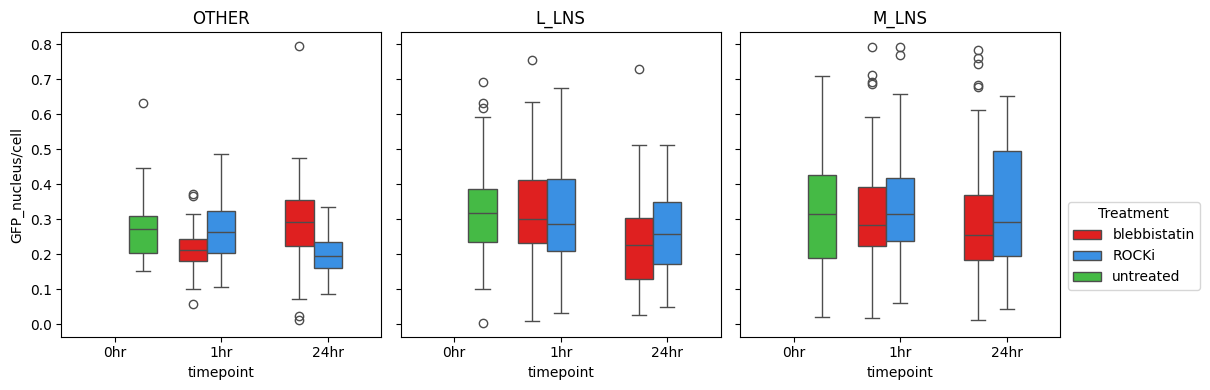

In [59]:
fix, ax = plt.subplots(ncols=3, figsize=(12, 4), sharey=True)

for i, cell_type in enumerate(data["cell_type"].unique()):
    sns.boxplot(
        data=data[data["cell_type"] == cell_type],
        x="timepoint",
        y="GFP_nucleus/cell",
        hue="treatment",
        ax=ax[i],
        order=["0hr", "1hr", "24hr"],
        palette=my_cols
    )
    ax[i].set_title(cell_type)
    # Remove individual legends
    ax[i].get_legend().remove()

# Add one shared legend to the right
handles, labels = ax[0].get_legend_handles_labels()
fix.legend(handles, labels, title="Treatment", bbox_to_anchor=(1.01, 0.5))

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on right for legend
plt.show()


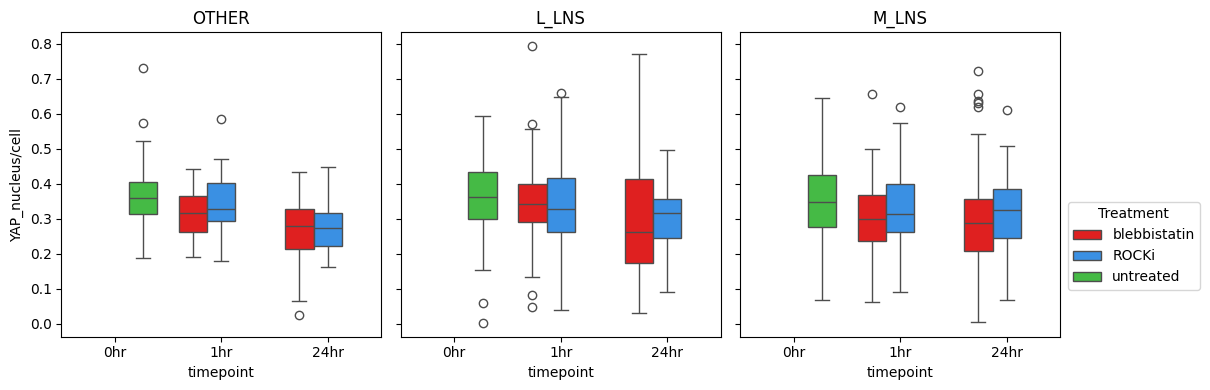

In [60]:
fix, ax = plt.subplots(ncols=3, figsize=(12, 4), sharey=True)

for i, cell_type in enumerate(data["cell_type"].unique()):
    sns.boxplot(
        data=data[data["cell_type"] == cell_type],
        x="timepoint",
        y="YAP_nucleus/cell",
        hue="treatment",
        ax=ax[i],
        order=["0hr", "1hr", "24hr"],
        palette=my_cols
    )
    ax[i].set_title(cell_type)
    # Remove individual legends
    ax[i].get_legend().remove()

# Add one shared legend to the right
handles, labels = ax[0].get_legend_handles_labels()
fix.legend(handles, labels, title="Treatment", bbox_to_anchor=(1.01, 0.5))

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on right for legend
plt.show()